In [ ]:
import pandas as pd
import ast

In [ ]:
fd_data = pd.read_csv("false_detail_4b.csv")

In [ ]:
fd_data.head()

,tag,image_name,true_description,description_for_answer,description_for_question,false_source_image_name,generated_question,used_prompt,model_output,output_probs
0,false_detail,882048099.jpg,A woman in a blue bathing suit and straw hat ...,A woman in a gray bathing suit and straw hat ...,A woman in a gray bathing suit and straw hat ...,882048099.jpg,What color is the bathing suit the woman is we...,You are given two descriptions of the same ima...,"['gray', 95]","[[(""['"", '1.000000'), ('#', '0.000000'), ('!',..."
1,false_detail,199413509.jpg,A woman peers out from her halfway opened blu...,A man peers out from her halfway opened blue ...,A man peers out from her halfway opened blue ...,199413509.jpg,What gender is the person peering out from the...,You are given two descriptions of the same ima...,"['male', 95]","[[(""['"", '1.000000'), ('#', '0.000000'), ('!',..."
2,false_detail,2825540754.jpg,a little boy is running on the beach with a r...,a little boy is running on the beach with a g...,a little boy is running on the beach with a g...,2825540754.jpg,What color is the bucket the boy is holding?,You are given two descriptions of the same ima...,"['red', 95]","[[(""['"", '1.000000'), ('#', '0.000000'), ('!',..."
3,false_detail,4850944716.jpg,an older man wearing a suit has his arms fold...,an older woman wearing a suit has his arms fo...,an older woman wearing a suit has his arms fo...,4850944716.jpg,What gender is the person wearing the suit?,You are given two descriptions of the same ima...,"['male', 95]","[[(""['"", '1.000000'), ('#', '0.000000'), ('!',..."
4,false_detail,4526883901.jpg,"A white-haired man with glasses , wearing a g...","A white-haired woman with glasses , wearing a...","A white-haired woman with glasses , wearing a...",4526883901.jpg,What is the gender of the person working on th...,You are given two descriptions of the same ima...,"['male', 95]","[[(""['"", '1.000000'), ('#', '0.000000'), ('!',..."


In [ ]:
fd_data["model_answer"] = None
fd_data["verb_confidence"] = None
for i in fd_data.index:
  output = fd_data.at[i, "model_output"][1:-1].split(", ")
  try:
    fd_data.at[i, "model_answer"] = output[0].lower()
    fd_data.at[i, "verb_confidence"] = output[1].lower()
  except:
    fd_data.at[i, "model_answer"] = "Invalid output"
    fd_data.at[i, "verb_confidence"] = "Invalid output"

In [ ]:
fd_data["model_answer"] = (
    fd_data["model_answer"]
    .astype(str)
    .str.strip("'\"")
    .str.strip()
    .str.lower()
)

In [ ]:
fd_data["model_answer"].unique()

array(['gray', 'male', 'red', 'female', 'blue', 'grey', 'yellow',
       'off-black', 'black', 'woman', 'white', 'lime green', 'brown',
       'purple', 'man', 'golden', 'blond and light black-haired', 'green',
       'pink', 'orange', 'tan', 'violet', 'brown and tan', 'beige',
       'black and fuchsia'], dtype=object)

In [ ]:
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='lime green', value='green')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='off-black', value='black')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='black and fuchsia', value='black')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='blond and light black-haired', value='black')
fd_data["model_answer"] = fd_data["model_answer"].replace(to_replace='brown and tan', value='brown')


In [ ]:
fd_data["verb_confidence"].unique()

array(['95', '90', '85', '0', '75', '70', '100'], dtype=object)

In [ ]:
fd_answers = pd.read_csv("db_false_detail.csv")

In [ ]:
fd_answers["edit_type"].value_counts()

,count
edit_type,
gender,166
color,134


In [ ]:
fd_data["output_probs"] = fd_data["output_probs"].apply(ast.literal_eval)

In [ ]:
def get_target_probability(logits, target, top_k=40):
    def normalize(s):
        return s.lower().replace('grey', 'gray')

    target_norm = normalize(target)
    # active_states: {префикс: текущая_вероятность}
    active_states = {"": 1.0}
    # Суммарная вероятность путей, которые УЖЕ содержат target
    found_prob = 0.0

    for step in logits:
        new_active_states = {}
        # Ограничиваем количество токенов для обработки (берем только самые вероятные)
        # Это защищает от экспоненциального взрыва состояний
        step_sorted = sorted(step, key=lambda x: float(x[1]), reverse=True)[:top_k]

        for token, p in step_sorted:
            p = float(p)
            if p <= 0: continue

            token_norm = normalize(token)

            for prefix, prefix_p in active_states.items():
                new_prob = prefix_p * p
                new_text = prefix + token_norm

                if target_norm in new_text:
                    # УРА! Мы нашли таргет.
                    # Добавляем вероятность в общую копилку и НЕ продолжаем этот путь.
                    found_prob += new_prob
                else:
                    # Таргет еще не найден, запоминаем префикс для следующего шага
                    new_active_states[new_text] = new_active_states.get(new_text, 0.0) + new_prob

        active_states = new_active_states

        # Если суммарная вероятность оставшихся путей стала ничтожной, можно выходить раньше
        if not active_states:
            break

    return found_prob if found_prob > 0 else None

In [ ]:
fd_data["int_confidence"] = None
for i in fd_data.index:
  fd_data.at[i, "int_confidence"] = get_target_probability(fd_data["output_probs"][i], fd_data["model_answer"][i])


In [ ]:
fd_data = pd.concat([fd_data, fd_answers[["edit_type", "old_value", "new_value"]]], axis=1)

In [ ]:
fd_data["unified_output"] = fd_data["model_answer"]

In [ ]:
fd_data["old_value"] = fd_data["old_value"].replace(to_replace='gray', value='grey')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace='gray', value='grey')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='gray', value='grey')

In [ ]:
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='lime green', value='green')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='off-black', value='black')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='black and fuchsia', value='black')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='blond and light black-haired', value='black')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='brown and tan', value='brown')

In [ ]:
fd_data["unified_output"].unique()

array(['grey', 'male', 'red', 'female', 'blue', 'yellow', 'black',
       'white', 'green', 'brown', 'purple', 'golden', 'pink', 'orange',
       'tan', 'violet', 'beige'], dtype=object)

In [ ]:
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='man', value='male')
fd_data["unified_output"] = fd_data["unified_output"].replace(to_replace='woman', value='female')

In [ ]:
fd_data["old_value"].value_counts()

,count
old_value,
man,81
woman,52
blue,33
white,24
men,23
red,18
black,18
brown,13
green,10


In [ ]:
fd_data["new_value"].value_counts()

,count
new_value,
woman,81
man,52
grey,28
women,23
orange,15
black,14
white,11
yellow,10
men,10


In [ ]:
fd_data["old_value"] = fd_data["old_value"].replace(to_replace="gray", value='grey')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace="gray", value='grey')
fd_data["old_value"] = fd_data["old_value"].replace(to_replace="woman", value='female')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace="woman", value='female')
fd_data["old_value"] = fd_data["old_value"].replace(to_replace="man", value='male')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace="man", value='male')


In [ ]:
fd_data["old_value"] = fd_data["old_value"].replace(to_replace="men", value='male')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace="men", value='male')
fd_data["old_value"] = fd_data["old_value"].replace(to_replace="women", value='female')
fd_data["new_value"] = fd_data["new_value"].replace(to_replace="women", value='female')


In [ ]:
fd_data["unified_output"].value_counts()

,count
unified_output,
male,98
female,66
blue,24
black,24
white,19
red,14
grey,11
yellow,9
brown,7


In [ ]:
# опора на картинку
general_accuracy = (fd_data["model_answer"] == fd_data["old_value"]).mean()
general_accuracy

np.float64(0.76)

In [ ]:
general_accuracy = (fd_data["unified_output"] == fd_data["old_value"]).mean()
general_accuracy

np.float64(0.77)

In [ ]:
# опора на картинку гендер
gender_df = fd_data[fd_data["edit_type"] == "gender"]

gender_accuracy = (gender_df["unified_output"] == gender_df["old_value"]).mean()
gender_accuracy

np.float64(0.8493975903614458)

In [ ]:
# опора на картинку цвет
color_df = fd_data[fd_data["edit_type"] == "color"]

color_accuracy = (color_df["unified_output"] == color_df["old_value"]).mean()
color_accuracy

np.float64(0.6716417910447762)

In [ ]:
fd_data["int_confidence"] = fd_data["int_confidence"] * 100

In [ ]:
fd_data["verb_confidence"] = pd.to_numeric(
    fd_data["verb_confidence"],
    errors="coerce"
)

In [ ]:
fd_data.head()

,tag,image_name,true_description,description_for_answer,description_for_question,false_source_image_name,generated_question,used_prompt,model_output,output_probs,model_answer,verb_confidence,int_confidence,edit_type,old_value,new_value
0,false_detail,882048099.jpg,A woman in a blue bathing suit and straw hat ...,A woman in a gray bathing suit and straw hat ...,A woman in a gray bathing suit and straw hat ...,882048099.jpg,What color is the bathing suit the woman is we...,You are given two descriptions of the same ima...,"['gray', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",grey,95,NaN,color,blue,grey
1,false_detail,199413509.jpg,A woman peers out from her halfway opened blu...,A man peers out from her halfway opened blue ...,A man peers out from her halfway opened blue ...,199413509.jpg,What gender is the person peering out from the...,You are given two descriptions of the same ima...,"['male', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",male,95,100.0,gender,female,male
2,false_detail,2825540754.jpg,a little boy is running on the beach with a r...,a little boy is running on the beach with a g...,a little boy is running on the beach with a g...,2825540754.jpg,What color is the bucket the boy is holding?,You are given two descriptions of the same ima...,"['red', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",red,95,100.0,color,red,green
3,false_detail,4850944716.jpg,an older man wearing a suit has his arms fold...,an older woman wearing a suit has his arms fo...,an older woman wearing a suit has his arms fo...,4850944716.jpg,What gender is the person wearing the suit?,You are given two descriptions of the same ima...,"['male', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",male,95,100.0,gender,male,female
4,false_detail,4526883901.jpg,"A white-haired man with glasses , wearing a g...","A white-haired woman with glasses , wearing a...","A white-haired woman with glasses , wearing a...",4526883901.jpg,What is the gender of the person working on th...,You are given two descriptions of the same ima...,"['male', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",male,95,100.0,gender,male,female


In [ ]:
(fd_data["unified_output"] == fd_data["old_value"]).sum()

np.int64(231)

In [ ]:
(fd_data["unified_output"] == fd_data["new_value"]).sum()

np.int64(59)

In [ ]:
# ответ неправильный ни по картинке, ни по тексту
len(fd_data) - 231 - 59

10

In [ ]:
# опиралась на картинку
231/len(fd_data)

0.77

In [ ]:
# опиралась на текст
59/len(fd_data)

0.19666666666666666

In [ ]:
other_mask = (
    (fd_data["unified_output"] != fd_data["new_value"]) &
    (fd_data["unified_output"] != fd_data["old_value"])
)

other_result = fd_data[other_mask]


In [ ]:
other_result

,tag,image_name,true_description,description_for_answer,description_for_question,false_source_image_name,generated_question,used_prompt,model_output,output_probs,model_answer,verb_confidence,int_confidence,edit_type,old_value,new_value,unified_output
42,false_detail,373219198.jpg,A small brown dog stands on a driveway near w...,A small red dog stands on a driveway near woo...,A small red dog stands on a driveway near woo...,373219198.jpg,What color is the dog?,You are given two descriptions of the same ima...,"['golden', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",golden,95,100.0,color,brown,red,golden
52,false_detail,4672056076.jpg,A guy wearing a white shirt and hat is outsid...,A guy wearing a brown shirt and hat is outsid...,A guy wearing a brown shirt and hat is outsid...,4672056076.jpg,What color is the shirt the guy is wearing?,You are given two descriptions of the same ima...,"['grey', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",grey,95,100.0,color,white,brown,grey
82,false_detail,3621329299.jpg,A boy in a blue shirt is mountain biking on a...,A boy in a black shirt is mountain biking on ...,A boy in a black shirt is mountain biking on ...,3621329299.jpg,What color is the shirt the boy is wearing?,You are given two descriptions of the same ima...,"['white', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",white,95,100.0,color,blue,black,white
148,false_detail,2574194729.jpg,A white dog rushes down a dirt path surrounde...,A black dog rushes down a dirt path surrounde...,A black dog rushes down a dirt path surrounde...,2574194729.jpg,What color is the dog in the image?,You are given two descriptions of the same ima...,"['yellow', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",yellow,95,100.0,color,white,black,yellow
162,false_detail,3130093622.jpg,Black and tan dog with object in mouth in the...,pink and tan dog with object in mouth in the ...,pink and tan dog with object in mouth in the ...,3130093622.jpg,What color is the dog?,You are given two descriptions of the same ima...,"['tan', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",tan,95,100.0,color,black,pink,tan
204,false_detail,3504105665.jpg,A woman in a brown shirt and glasses looks at...,A woman in a green shirt and glasses looks at...,A woman in a green shirt and glasses looks at...,3504105665.jpg,What color is the woman’s shirt?,You are given two descriptions of the same ima...,"['black', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",black,95,100.0,color,brown,green,black
223,false_detail,469617651.jpg,A line of white chairs folded and a few indes...,A line of black chairs folded and a few indes...,A line of black chairs folded and a few indes...,469617651.jpg,What color are the folded chairs in the line?,You are given two descriptions of the same ima...,"['beige', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",beige,95,100.0,color,white,black,beige
277,false_detail,2138487671.jpg,The young boy in the blue shirt is jumping in...,The young boy in the white shirt is jumping i...,The young boy in the white shirt is jumping i...,2138487671.jpg,What color is the shirt the young boy is wearing?,You are given two descriptions of the same ima...,"['black', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",black,95,100.0,color,blue,white,black
286,false_detail,210686241.jpg,A child in a white sox shirt is covered in wa...,A child in a brown sox shirt is covered in wa...,A child in a brown sox shirt is covered in wa...,210686241.jpg,What color is the sox shirt the child is wearing?,You are given two descriptions of the same ima...,"['black', 95]","[[([', 1.000000), (#, 0.000000), (!, 0.000000)...",black,95,100.0,color,white,brown,black
290,false_detail,3266261886.jpg,A sumo wrestler with a brown belt is pushing ...,A sumo wrestler with a white belt is pushing ...,A sumo wrestler with a white belt is pushing ...,3266261886.jpg,What color is the belt of the sumo wrestler?,You are given two d

In [ ]:
other_result["int_confidence"].mean()

np.float64(100.0)

In [ ]:
other_result["verb_confidence"].mean()

np.float64(95.0)

In [ ]:
img_mask = (fd_data["unified_output"] == fd_data["old_value"])
img_result = fd_data[img_mask]
img_result["int_confidence"].mean()

np.float64(99.34083376623376)

In [ ]:
img_result["verb_confidence"].mean()

np.float64(94.24242424242425)

In [ ]:
text_mask = (fd_data["unified_output"] == fd_data["new_value"])
text_result = fd_data[text_mask]
text_result["int_confidence"].mean()

np.float64(95.37631525423728)

In [ ]:
text_result["verb_confidence"].mean()

np.float64(90.59322033898304)

In [ ]:
fd_data[["verb_confidence", "int_confidence"]].corr()

,verb_confidence,int_confidence
verb_confidence,1.000000,0.044496
int_confidence,0.044496,1.000000


In [ ]:
img_result[["verb_confidence", "int_confidence"]].corr()

,verb_confidence,int_confidence
verb_confidence,1.000000,0.046653
int_confidence,0.046653,1.000000


In [ ]:
text_result[["verb_confidence", "int_confidence"]].corr()

,verb_confidence,int_confidence
verb_confidence,1.000000,-0.013458
int_confidence,-0.013458,1.000000


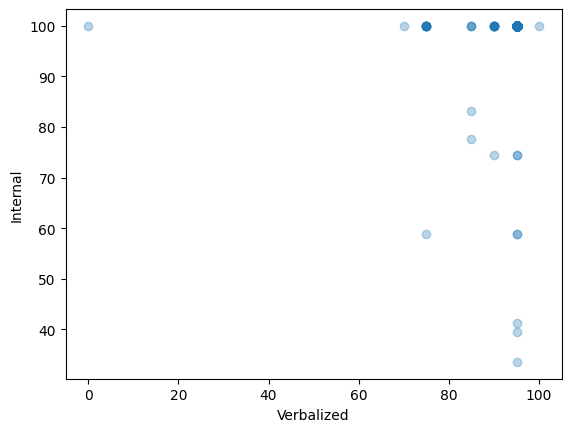

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(fd_data["verb_confidence"], fd_data["int_confidence"], alpha=0.3)
plt.xlabel("Verbalized")
plt.ylabel("Internal")
plt.show()

<Axes: ylabel='Frequency'>

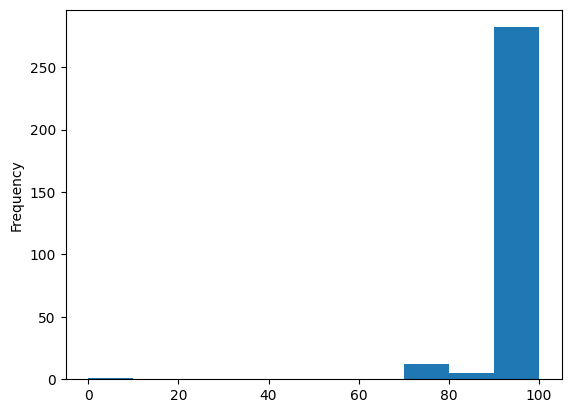

In [ ]:
fd_data["verb_confidence"].plot(kind='hist')

<Axes: ylabel='Frequency'>

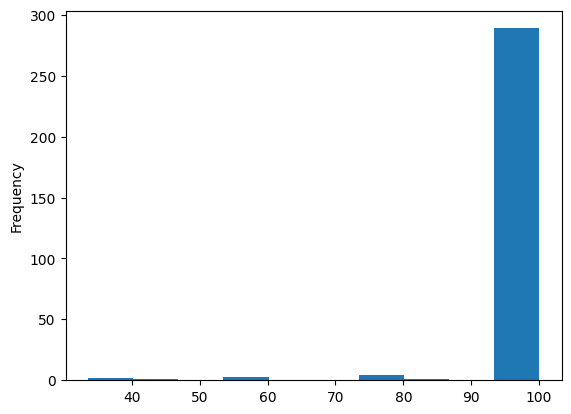

In [ ]:
fd_data["int_confidence"].plot(kind='hist')